# 🎼 Song Clustering with KMeans and DBSCAN

## 🎯 Objective
The goal of this project is to analyze a dataset of songs using unsupervised learning techniques in order to identify natural patterns in the data.

Two clustering approaches are applied:
- KMeans → centroid-based clustering
- DBSCAN → density-based clustering

Additionally, PCA (Principal Component Analysis) is used to reduce dimensionality and visualize the results in a 2D space.


        core_features [] =
                        - danceability
                        - energy
                        x valence (too correlated... out)
                        - tempo
                        x loudness (too correlated... out)
     (for the big .csv)     +
                        - acousticness,
                        - instrumentalness,
                        - speechiness



## 📦 Bibliotheken importieren

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## 📊 Daten laden

In [7]:
pre_df = pd.read_csv("./data/df_audio_features_1000.csv")
features = [
    "danceability",
    "energy",
    "tempo",
    "acousticness",
    "instrumentalness",
    "speechiness"
]

df_model = pre_df[features].copy()
df_model.head()

,danceability,energy,tempo,acousticness,instrumentalness,speechiness
0,0.624,0.468,74.139,0.881,0.000006,0.1320
1,0.585,0.247,127.150,0.452,0.000009,0.0400
2,0.290,0.227,114.278,0.944,0.000079,0.0311
3,0.540,0.681,88.385,0.808,0.000000,0.0508
4,0.455,0.167,76.118,0.918,0.000000,0.0739


## 👀 Visualize (pre-train)


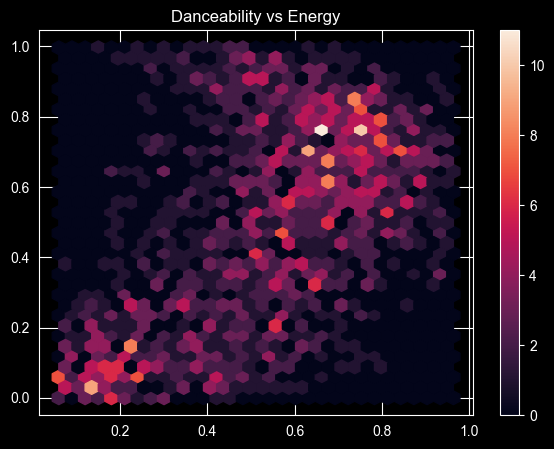

In [8]:
plt.figure(figsize=(7,5))
plt.hexbin(
    df_model["danceability"],
    df_model["energy"],
    gridsize=30
)
plt.colorbar()
plt.title("Danceability vs Energy")
plt.show()

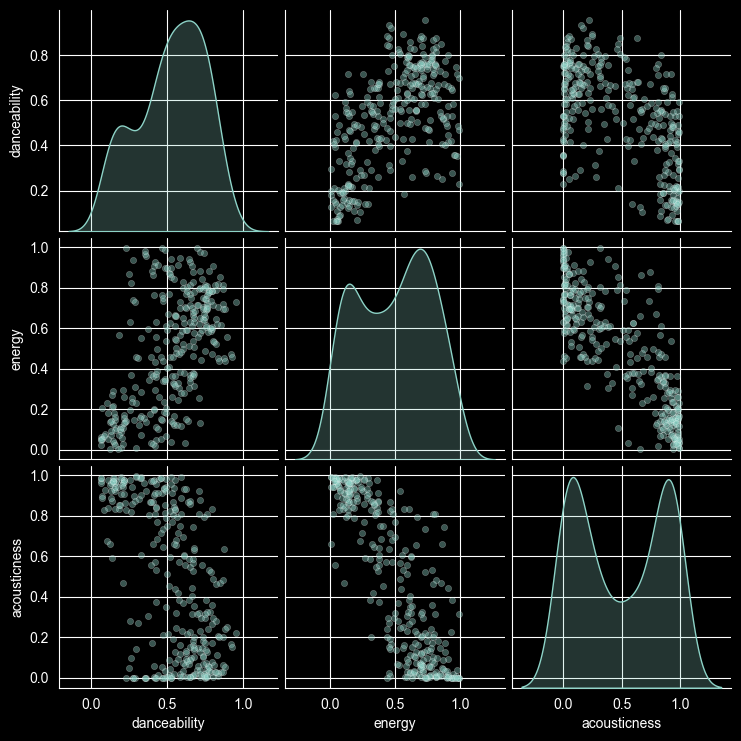

In [9]:
features_plot = [
    "danceability",
    "energy",
    "acousticness"
]

df_sample = df_model.sample(300, random_state=42)

sns.pairplot(
    df_sample,
    vars=features_plot,
    plot_kws={"alpha": 0.4, "s": 20},
    diag_kind="kde"
)

plt.show()

In [10]:
print(df_model.corr())

                  danceability    energy     tempo  acousticness  \
danceability          1.000000  0.545512  0.074740     -0.579392   
energy                0.545512  1.000000  0.285091     -0.818499   
tempo                 0.074740  0.285091  1.000000     -0.249964   
acousticness         -0.579392 -0.818499 -0.249964      1.000000   
instrumentalness     -0.535295 -0.487391 -0.126451      0.475025   
speechiness           0.373654  0.356334  0.104111     -0.379788   

                  instrumentalness  speechiness  
danceability             -0.535295     0.373654  
energy                   -0.487391     0.356334  
tempo                    -0.126451     0.104111  
acousticness              0.475025    -0.379788  
instrumentalness          1.000000    -0.238243  
speechiness              -0.238243     1.000000  


## ⚖️ Feature-Skalierung

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

## 🧠 Create Modell

### 🔹 Elbow method & Silhouette

In [12]:
inertia = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}, silhouette={sil_scores[-1]:.3f}")

k=2, silhouette=0.357
k=3, silhouette=0.294
k=4, silhouette=0.316
k=5, silhouette=0.297
k=6, silhouette=0.275
k=7, silhouette=0.255
k=8, silhouette=0.249
k=9, silhouette=0.259


### 📙 KMeans

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

### 📗 DBScan

In [14]:
for eps in [0.8, 1.0, 1.2, 1.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    print(f"eps={eps}: {set(labels)}")

dbscan = DBSCAN(eps=1.2, min_samples=2)
dbscan_labels = dbscan.fit_predict(X_scaled)

eps=0.8: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}
eps=1.0: {np.int64(0), np.int64(1), np.int64(-1)}
eps=1.2: {np.int64(0), np.int64(-1)}
eps=1.5: {np.int64(0), np.int64(-1)}


## 👀 Visualize (pos-train) PCA 2D

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.50694041 0.16394908]
Total explained variance: 0.6708894871388845


## 📖 Plot Dataframe

In [22]:
df_plot = df_model.copy()

df_plot["pca1"] = X_pca[:, 0]
df_plot["pca2"] = X_pca[:, 1]

df_plot["kmeans_cluster"] = kmeans_labels
df_plot["dbscan_cluster"] = dbscan_labels

## 💸 Validation

In [17]:
print("Shape:", df_plot.shape)

print("\n\nColumns:")
print(df_plot.columns)

print("\n\nCluster distribution (KMeans):")
print(df_plot["kmeans_cluster"].value_counts())

print("\n\nCluster distribution (DBSCAN):")
print(df_plot["dbscan_cluster"].value_counts())

print("\n\nSample:")
print(df_plot.head())

Shape: (1440, 10)


Columns:
Index(['danceability', 'energy', 'tempo', 'acousticness', 'instrumentalness',
       'speechiness', 'pca1', 'pca2', 'kmeans_cluster', 'dbscan_cluster'],
      dtype='object')


Cluster distribution (KMeans):
kmeans_cluster
2    588
3    395
1    262
0    195
Name: count, dtype: int64


Cluster distribution (DBSCAN):
dbscan_cluster
 0    1419
-1      16
 2       3
 1       2
Name: count, dtype: int64


Sample:
   danceability  energy    tempo  acousticness  instrumentalness  speechiness  \
0         0.624   0.468   74.139         0.881          0.000006       0.1320   
1         0.585   0.247  127.150         0.452          0.000009       0.0400   
2         0.290   0.227  114.278         0.944          0.000079       0.0311   
3         0.540   0.681   88.385         0.808          0.000000       0.0508   
4         0.455   0.167   76.118         0.918          0.000000       0.0739   

       pca1      pca2  kmeans_cluster  dbscan_cluster  
0  0.276100 -1.

### 📙 KMeans plot

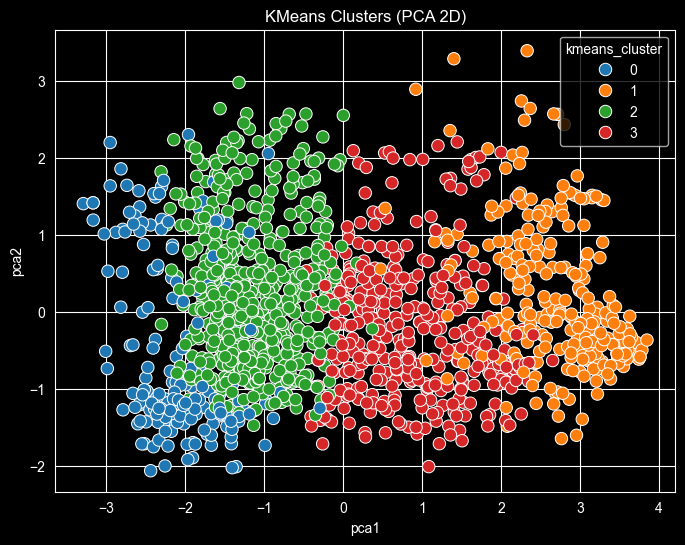

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_plot,
    x="pca1",
    y="pca2",
    hue="kmeans_cluster",
    palette="tab10",
    s=80
)
plt.title("KMeans Clusters (PCA 2D)")
plt.show()

### 📗 DBScan Plot

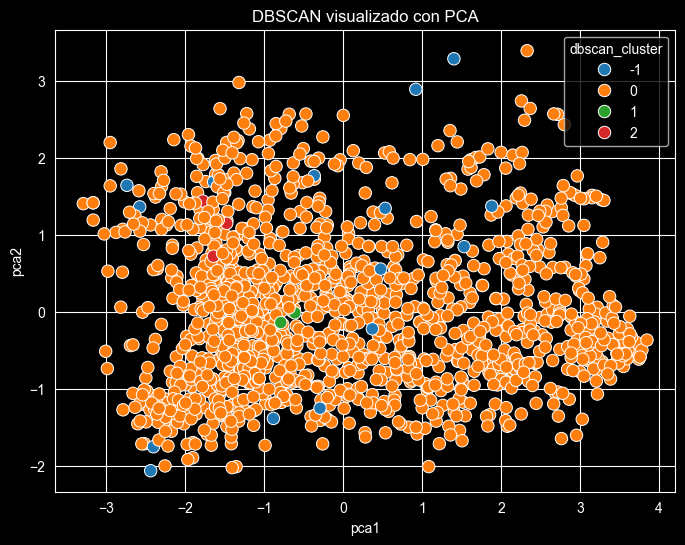

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_plot,
    x="pca1",
    y="pca2",
    hue="dbscan_cluster",
    palette="tab10",
    s=80
)
plt.title("DBSCAN visualizado con PCA")
plt.show()

## 📈 Clusters interpretation

### 📙 KMeans

In [20]:
print("KMeans cluster means")
print(df_plot.groupby("kmeans_cluster")[features].mean())

KMeans cluster means
                danceability    energy       tempo  acousticness  \
kmeans_cluster                                                     
0                   0.737303  0.699636  116.558185      0.164656   
1                   0.280507  0.161178  101.770824      0.898275   
2                   0.636816  0.705403  125.105027      0.169229   
3                   0.466648  0.299423  108.871132      0.783574   

                instrumentalness  speechiness  
kmeans_cluster                                 
0                       0.020600     0.276785  
1                       0.836664     0.043498  
2                       0.051597     0.067291  
3                       0.045194     0.048852  


### 📗 DBScan

In [21]:
print("\nDBSCAN cluster means")
print(df_plot.groupby("dbscan_cluster")[features].mean())


DBSCAN cluster means
                danceability    energy       tempo  acousticness  \
dbscan_cluster                                                     
-1                  0.529375  0.390594  142.859375      0.339638   
 0                  0.539031  0.494427  114.878779      0.472844   
 1                  0.185000  0.995000   87.651000      0.000275   
 2                  0.771667  0.625333  161.538667      0.024574   

                instrumentalness  speechiness  
dbscan_cluster                                 
-1                      0.404114     0.238519  
 0                      0.184493     0.083996  
 1                      0.415500     0.179000  
 2                      0.773667     0.289667  
